# **Heart Disease Prediction Using a Hybrid Feature Selection and Ensemble Learning Approach**<br>

## [Kelompok 5] Project Data Science KOM

Anggota Kelompok:<br>
Mikail Achmad (24/542370/PA/23026)<br>
Marco Christian	(24/539714/PA/22915)<br>
Thufail Bahir Al Bariq	(24/537843/PA/22801)<br>
Erdizah Ghodi Al Haidar	(24/537670/PA/22787)<br>

In [23]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

In [24]:
PATH = './dataset/heart_disease_cleveland.csv'
df = pd.read_csv(PATH)

## EDA

In [25]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [26]:
df.shape

(303, 14)

In [27]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [29]:
# Paper mendefinisikan 'target' sebagai indikator biner (0 = tidak ada penyakit jantung, 1 = ada penyakit jantung).
df["target"].value_counts().sort_index()

target
0    164
1    139
Name: count, dtype: int64

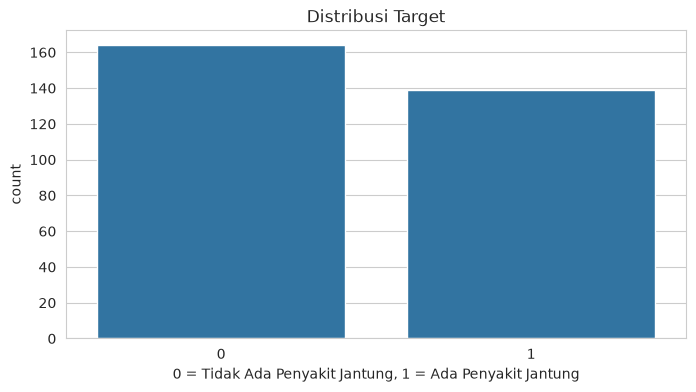

In [30]:
sns.countplot(data=df, x="target")
plt.title("Distribusi Target")
plt.xlabel("0 = Tidak Ada Penyakit Jantung, 1 = Ada Penyakit Jantung")
plt.show()

In [31]:
# Cek missing values
df.isnull().sum().sort_values(ascending=False)

ca          4
thal        2
cp          0
trestbps    0
age         0
sex         0
fbs         0
chol        0
restecg     0
thalach     0
oldpeak     0
exang       0
slope       0
target      0
dtype: int64

In [32]:
# Cek duplikat
df.duplicated().sum()

np.int64(0)

In [33]:
# Cek nilai 0 yang secara medis tidak valid
df[["trestbps", "chol"]].eq(0).sum()

trestbps    0
chol        0
dtype: int64

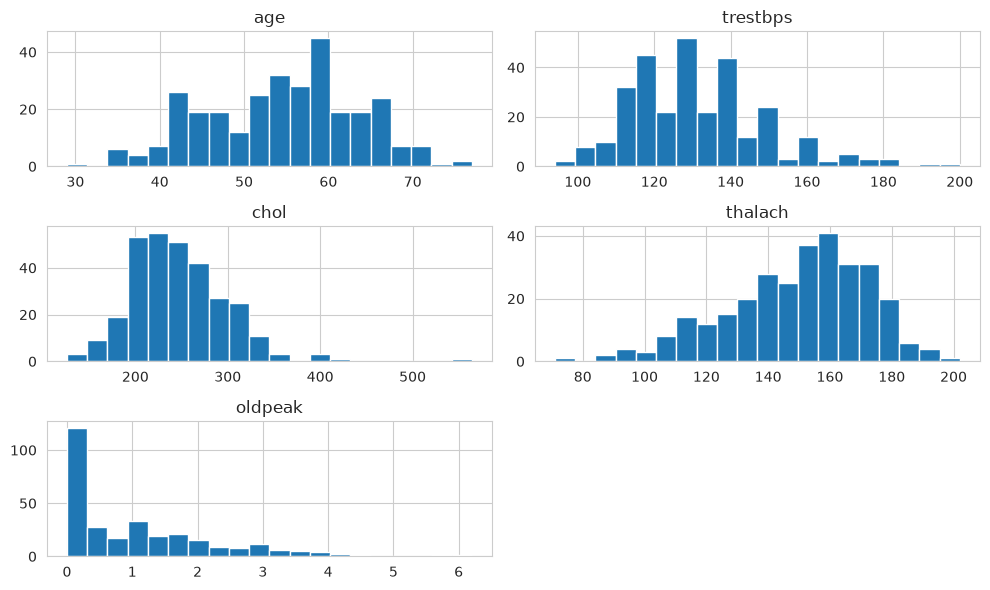

In [34]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[numeric_cols].hist(figsize=(10, 6), bins=20)
plt.tight_layout()
plt.show()

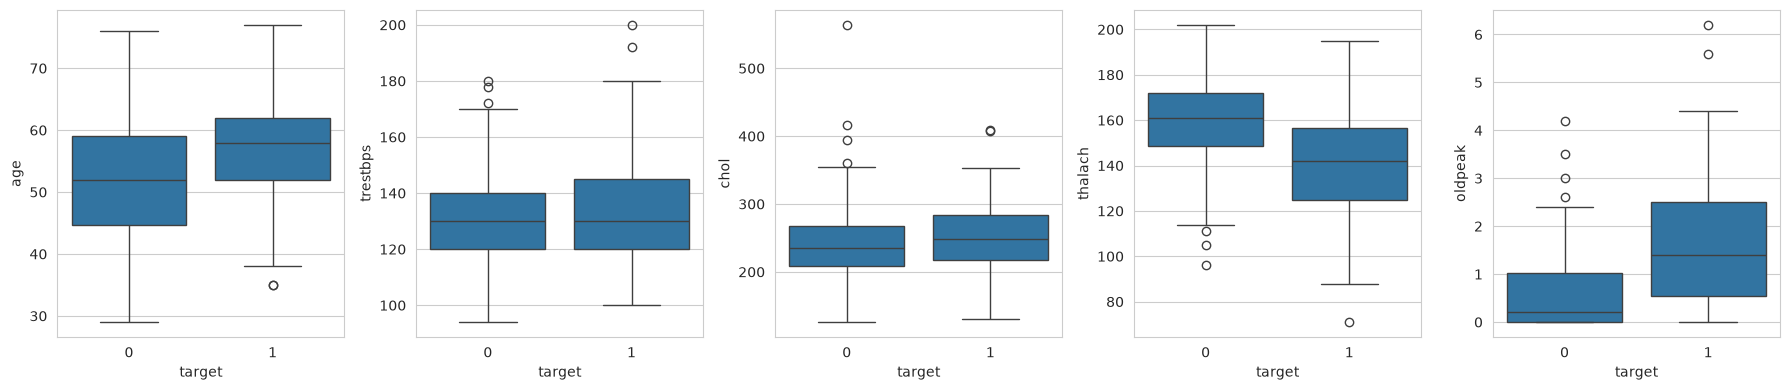

In [35]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="target", y=col, ax=ax)
plt.tight_layout()
plt.show()

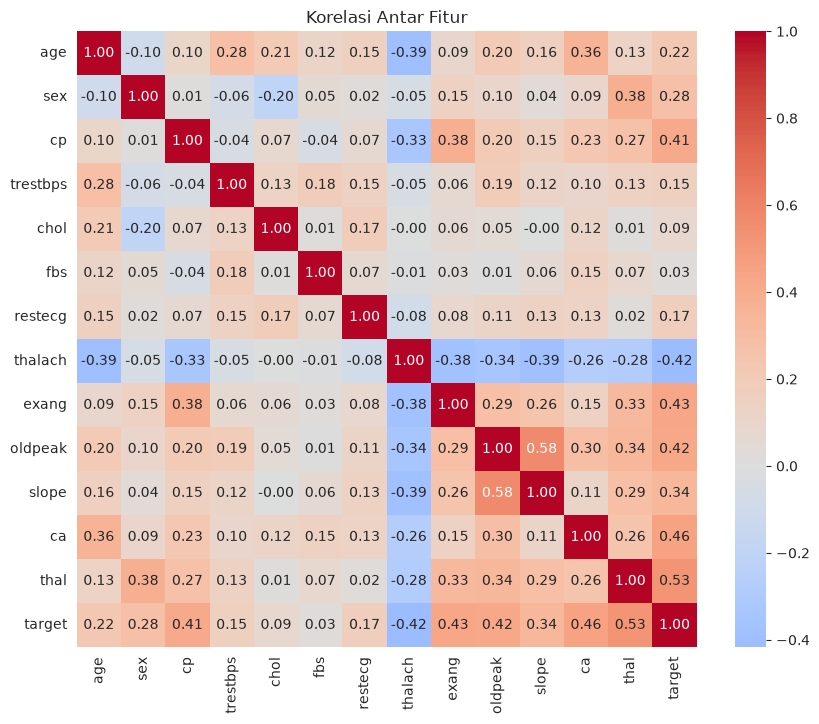

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Antar Fitur")
plt.show()

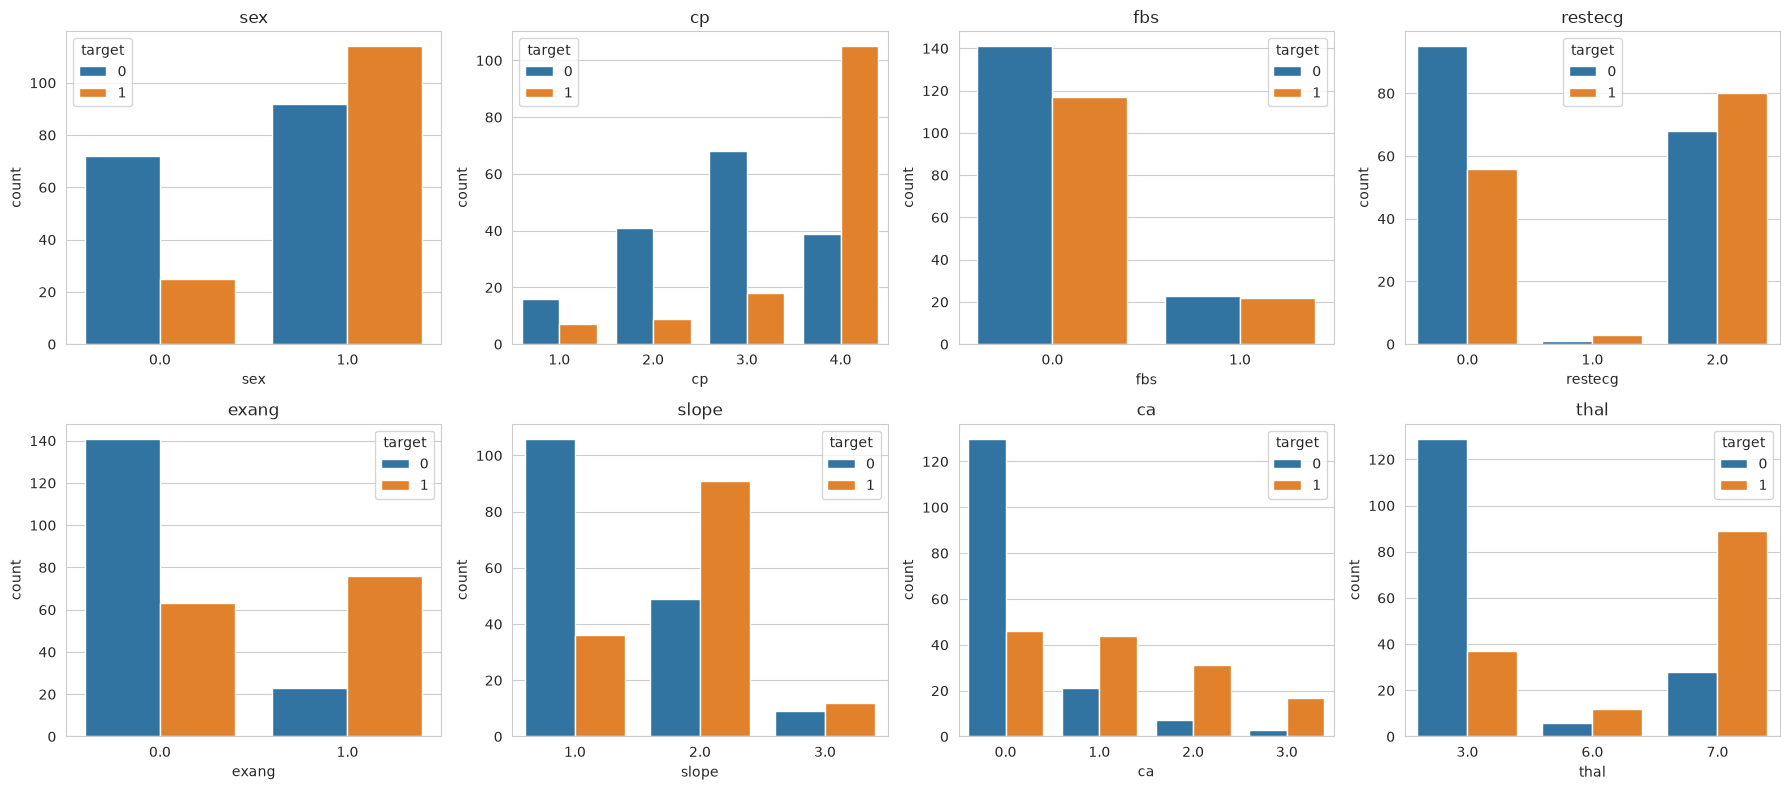

In [37]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df, x=col, hue="target", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Preprocessing

In [38]:
# harmonize target column name to match the paper's 'Num' (0 = no disease, 1 = disease)
target_col = "target" if "target" in df.columns else df.columns[-1]
df = df.rename(columns={target_col: "num"})

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [39]:
def iqr_bounds_from(data: pd.DataFrame, cols) -> dict:
    bounds = {}
    for c in cols:
        q1, q3 = data[c].quantile(0.25), data[c].quantile(0.75)
        iqr = q3 - q1
        bounds[c] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return bounds


def apply_iqr(data: pd.DataFrame, bounds: dict, drop: bool) -> pd.DataFrame:
    out = data.copy()
    mask = pd.Series(True, index=out.index)
    for c, (lower, upper) in bounds.items():
        if drop:
            mask &= out[c].between(lower, upper)
        else:
            out[c] = out[c].clip(lower, upper)
    return out[mask].reset_index(drop=True) if drop else out


target_col = "num"
feature_cols = [c for c in df.columns if c != target_col]
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
continuous_cols = [c for c in continuous_cols if c in df.columns]

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[target_col]
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for c in ["trestbps", "chol"]:
    if c in train_df.columns:
        train_df[c] = train_df[c].replace(0, np.nan)
        test_df[c] = test_df[c].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")
train_df[continuous_cols] = imputer.fit_transform(train_df[continuous_cols])
test_df[continuous_cols] = imputer.transform(test_df[continuous_cols])

# batas IQR dihitung dari training set saja, lalu dipakai untuk keduanya
bounds = iqr_bounds_from(train_df, continuous_cols)
n_before = len(train_df)
train_df = apply_iqr(train_df, bounds, drop=True)
test_df = apply_iqr(test_df, bounds, drop=False)
print(f"Instances before IQR removal: {n_before} -> after: {len(train_df)}")

scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df[target_col].to_numpy(dtype=int)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df[target_col].to_numpy(dtype=int)
n_features = X_train.shape[1]

X, y = X_train, y_train  # feature selection di bawah hanya boleh melihat training set

print(f"Train matrix: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test matrix:  X_test={X_test.shape}, y_test={y_test.shape}, n_features={n_features}")
feature_cols

Instances before IQR removal: 242 -> after: 227
Train matrix: X_train=(227, 13), y_train=(227,)
Test matrix:  X_test=(61, 13), y_test=(61,), n_features=13


['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

# Feature Extraction

## 4. Fitness function (wrapper method)

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [41]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

_fitness_cache = {}
_clf_template = dict(n_estimators=10, max_depth=5, n_jobs=1, random_state=RNG_SEED)
_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG_SEED)


def sigmoid(v):
    return 1 / (1 + np.exp(-v))


def to_binary_mask(vec):
    '''Continuous search vector -> boolean feature mask via sigmoid thresholding.'''
    probs = sigmoid(vec)
    mask = probs > 0.5
    if not mask.any():  # never allow the empty subset
        mask[np.argmax(probs)] = True
    return mask


def objective_value(vec) -> float:
    '''Lower is better (this is what the paper's Fig. 3 plots).'''
    mask = to_binary_mask(vec)
    key = mask.tobytes()
    if key in _fitness_cache:
        return _fitness_cache[key]

    Xs = X[:, mask]
    acc = cross_val_score(
        RandomForestClassifier(**_clf_template), Xs, y, cv=_cv, scoring="accuracy"
    ).mean()

    frac_selected = mask.sum() / len(mask)
    obj = 100.0 * ((1 - acc) + 0.01 * frac_selected)
    _fitness_cache[key] = obj
    return obj


def fitness_from_objective(obj):
    '''Higher is better; used where an algorithm expects a fitness to maximize.'''
    return -obj


## 5. Standalone Genetic Algorithm (paper, Section IV-A-1)

In [42]:

def genetic_algorithm(n_features, pop_size=10, generations=20,
                       crossover_prob=0.9, mutation_prob=0.05, seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    population = local_rng.uniform(-1, 1, size=(pop_size, n_features))
    history = []

    def evaluate(pop):
        return np.array([objective_value(ind) for ind in pop])

    obj_vals = evaluate(population)
    best_idx = obj_vals.argmin()
    best_vec, best_obj = population[best_idx].copy(), obj_vals[best_idx]
    history.append(best_obj)

    for _ in range(generations):
        fitness = fitness_from_objective(obj_vals)
        fitness_shifted = fitness - fitness.min() + 1e-6  # roulette needs positives
        probs = fitness_shifted / fitness_shifted.sum()

        # 1) Selection (roulette wheel)
        parents_idx = local_rng.choice(pop_size, size=pop_size, p=probs)
        parents = population[parents_idx]

        # 2) Crossover (single-point)
        children = parents.copy()
        for i in range(0, pop_size - 1, 2):
            if local_rng.random() < crossover_prob:
                point = local_rng.integers(1, n_features)
                children[i, point:], children[i + 1, point:] = (
                    parents[i + 1, point:].copy(), parents[i, point:].copy(),
                )

        # 3) Mutation
        mut_mask = local_rng.random(children.shape) < mutation_prob
        children[mut_mask] += local_rng.normal(0, 0.5, size=mut_mask.sum())

        # 4) Replacement (elitism: keep the best individual seen so far)
        children[0] = best_vec
        population = children

        obj_vals = evaluate(population)
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < best_obj:
            best_obj, best_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()
        history.append(best_obj)

    return best_vec, best_obj, history


ga_best_vec, ga_best_obj, ga_history = genetic_algorithm(n_features)
print(f"GA best objective: {ga_best_obj:.3f}")
print(f"GA selected features: {[f for f,m in zip(feature_cols, to_binary_mask(ga_best_vec)) if m]}")


GA best objective: 20.428
GA selected features: ['age', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'ca', 'thal']


## 6. Standalone Cuckoo Search Algorithm (paper, Section IV-A-2)

In [43]:

def levy_flight(shape, beta=1.5, rng=rng):
    # Mantegna's algorithm for Levy-distributed steps
    num = math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma_u = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma_u, size=shape)
    v = rng.normal(0, 1, size=shape)
    return u / (np.abs(v) ** (1 / beta))


def cuckoo_search(n_features, n_nests=15, iterations=20, pa=0.25, levy_lambda=1.5,
                   seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    nests = local_rng.uniform(-1, 1, size=(n_nests, n_features))
    obj_vals = np.array([objective_value(n) for n in nests])
    best_idx = obj_vals.argmin()
    best_vec, best_obj = nests[best_idx].copy(), obj_vals[best_idx]
    history = [best_obj]

    for _ in range(iterations):
        # Levy-flight guided new solutions
        step = levy_flight(nests.shape, beta=levy_lambda, rng=local_rng)
        new_nests = nests + 0.01 * step * (nests - best_vec)
        new_obj = np.array([objective_value(n) for n in new_nests])

        improved = new_obj < obj_vals
        nests[improved] = new_nests[improved]
        obj_vals[improved] = new_obj[improved]

        # a fraction pa of the worst nests are abandoned and rebuilt randomly
        n_abandon = int(pa * n_nests)
        worst_idx = np.argsort(obj_vals)[-n_abandon:]
        nests[worst_idx] = local_rng.uniform(-1, 1, size=(n_abandon, n_features))
        obj_vals[worst_idx] = [objective_value(n) for n in nests[worst_idx]]

        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < best_obj:
            best_obj, best_vec = obj_vals[gen_best_idx], nests[gen_best_idx].copy()
        history.append(best_obj)

    return best_vec, best_obj, history


csa_best_vec, csa_best_obj, csa_history = cuckoo_search(n_features)
print(f"CSA best objective: {csa_best_obj:.3f}")
print(f"CSA selected features: {[f for f,m in zip(feature_cols, to_binary_mask(csa_best_vec)) if m]}")


CSA best objective: 19.486
CSA selected features: ['cp', 'chol', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 7. Hybrid GA + CSO (paper, *Algorithm 1*)

In [44]:

def hybrid_ga_cso(n_features, pop_size=15, generations=20, mutation_prob=0.05,
                   random_walk_prob=0.25, crossover_prob=0.9, delta=5,
                   levy_lambda=1.5, seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    population = local_rng.uniform(-1, 1, size=(pop_size, n_features))

    obj_vals = np.array([objective_value(ind) for ind in population])
    best_idx = obj_vals.argmin()
    gbest_vec, gbest_obj = population[best_idx].copy(), obj_vals[best_idx]
    history = [gbest_obj]
    stagnant_count = 0

    for _ in range(generations):
        # (3) fitness already computed as obj_vals from previous iteration

        # (4-6) Levy-flight-based update toward the global best, then refresh gbest
        step = levy_flight(population.shape, beta=levy_lambda, rng=local_rng)
        alpha = 0.01
        population = population + alpha * step * (population - gbest_vec)

        obj_vals = np.array([objective_value(ind) for ind in population])
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()

        # (7-11) random-walk step for a random subset of individuals, then repair + re-evaluate
        do_walk = local_rng.random(pop_size) > (1 - random_walk_prob)
        idx_pool = np.arange(pop_size)
        for i in np.where(do_walk)[0]:
            xk, xj = population[local_rng.choice(idx_pool, 2, replace=False)]
            population[i] = population[i] + local_rng.random() * (xk - xj)
        population = np.clip(population, -3, 3)  # "repair the solution"
        obj_vals = np.array([objective_value(ind) for ind in population])

        # (12) update global best again after the random-walk pass
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()
            stagnant_count = 0
        else:
            stagnant_count += 1

        # (13-14) swap mutation if global best hasn't improved for `delta` generations
        if stagnant_count >= delta:
            mut_idx = local_rng.integers(0, pop_size)
            i, j = local_rng.choice(n_features, 2, replace=False)
            population[mut_idx, [i, j]] = population[mut_idx, [j, i]]
            if local_rng.random() < mutation_prob:
                population[mut_idx] += local_rng.normal(0, 0.5, size=n_features)
            stagnant_count = 0

        # (15) final evaluate/update pass for this generation
        obj_vals = np.array([objective_value(ind) for ind in population])
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()

        history.append(gbest_obj)

    return gbest_vec, gbest_obj, history  # (16) final solution


hybrid_best_vec, hybrid_best_obj, hybrid_history = hybrid_ga_cso(n_features)
print(f"Hybrid GA+CSO best objective: {hybrid_best_obj:.3f}")
print(f"Hybrid selected features: {[f for f,m in zip(feature_cols, to_binary_mask(hybrid_best_vec)) if m]}")


Hybrid GA+CSO best objective: 18.372
Hybrid selected features: ['cp', 'chol', 'ca', 'thal']


## 8. Convergence comparison (reproducing the shape of Figure 3)

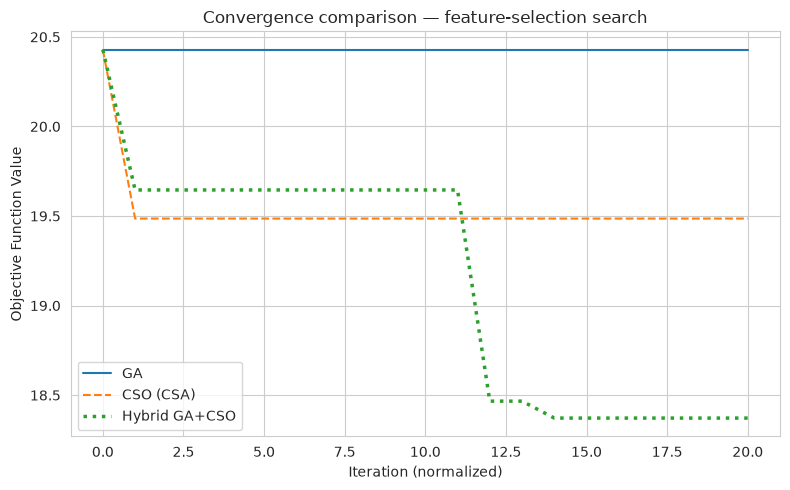

Final objective — GA: 20.428 | CSO: 19.486 | Hybrid GA+CSO: 18.372


In [45]:

def align_length(hist, target_len):
    '''Iteration counts differ (20 vs 100) -- resample onto a common x-axis for plotting.'''
    x_old = np.linspace(0, 1, len(hist))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, hist)


max_len = max(len(ga_history), len(csa_history), len(hybrid_history))

plt.figure(figsize=(8, 5))
plt.plot(align_length(ga_history, max_len), label="GA", linestyle="-")
plt.plot(align_length(csa_history, max_len), label="CSO (CSA)", linestyle="--")
plt.plot(align_length(hybrid_history, max_len), label="Hybrid GA+CSO", linestyle=":", linewidth=2.5)
plt.xlabel("Iteration (normalized)")
plt.ylabel("Objective Function Value")
plt.title("Convergence comparison — feature-selection search")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final objective — GA: {ga_history[-1]:.3f} | CSO: {csa_history[-1]:.3f} | Hybrid GA+CSO: {hybrid_history[-1]:.3f}")


In [46]:

def run_trial(seed):
    _, ga_obj, _ = genetic_algorithm(n_features, seed=seed)
    _, csa_obj, _ = cuckoo_search(n_features, n_nests=15, iterations=20, seed=seed)
    _, hyb_obj, _ = hybrid_ga_cso(n_features, pop_size=15, generations=20, seed=seed)
    return ga_obj, csa_obj, hyb_obj


trials = [run_trial(seed) for seed in range(5)]
trial_df = pd.DataFrame(trials, columns=["GA", "CSA", "Hybrid GA+CSO"])
trial_df.index.name = "seed"
trial_df.loc["mean"] = trial_df.mean()
trial_df.loc["std"] = trial_df.iloc[:-1].std()
trial_df


,GA,CSA,Hybrid GA+CSO
seed,,,
0,17.873594,18.685560,18.306343
1,19.124157,19.734143,17.358075
2,18.602789,19.047233,20.499325
3,19.841655,20.291948,19.681961
4,21.969411,20.024741,21.026541
mean,19.482321,19.556725,19.374449
std,1.565615,0.672603,1.524462


## 9. Selected feature subsets — side by side

In [47]:

def selected_features(vec):
    mask = to_binary_mask(vec)
    return {f: bool(m) for f, m in zip(feature_cols, mask)}

summary = pd.DataFrame({
    "GA": selected_features(ga_best_vec),
    "CSO (CSA)": selected_features(csa_best_vec),
    "Hybrid GA+CSO": selected_features(hybrid_best_vec),
})
summary.loc["n_selected"] = summary.sum()
summary.loc["final_objective"] = [ga_history[-1], csa_history[-1], hybrid_history[-1]]
summary


,GA,CSO (CSA),Hybrid GA+CSO
age,1.00000,0.00000,0.00000
sex,0.00000,0.00000,0.00000
cp,1.00000,1.00000,1.00000
trestbps,1.00000,0.00000,0.00000
chol,0.00000,1.00000,1.00000
fbs,1.00000,0.00000,0.00000
restecg,1.00000,1.00000,0.00000
thalach,1.00000,0.00000,0.00000
exang,0.00000,1.00000,0.00000
oldpeak,0.00000,0.00000,0.00000


## 10. Theoretical complexity (paper, Section VI-C)

In [48]:

# paper's Table 2 values (not this notebook's reduced demo budget)
P_ga, G_ga = 10, 20
n_nests_csa, T_csa = 50, 100
P_hybrid, G_hybrid = 50, 100

print(f"GA complexity term:          P*G       = {P_ga * G_ga}")
print(f"CSA complexity term:         n*T       = {n_nests_csa * T_csa}")
print(f"Hybrid GA+CSO complexity:    P*G + n*I = {P_hybrid * G_hybrid} (dominant term)")
print(f"\nNumber of features in this dataset (n): {n_features}")


GA complexity term:          P*G       = 200
CSA complexity term:         n*T       = 5000
Hybrid GA+CSO complexity:    P*G + n*I = 5000 (dominant term)

Number of features in this dataset (n): 13


# Modeling

#### Random Forest

In [49]:
# rf = RandomForestClassifier(
#     n_estimators=194,
#     max_depth=43,
#     random_state=42
# )

# rf.fit(X_train, y_train)

#### CNN

In [50]:
# cnn = Sequential([
#     Conv1D(
#         filters=34,
#         kernel_size=2,
#         activation='relu',
#         input_shape=(X_train.shape[1], 1)
#     ),

#     MaxPooling1D(pool_size=2),

#     Flatten(),

#     Dense(50, activation='relu'),

#     Dense(1, activation='sigmoid')
# ])

# cnn.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

In [51]:
# X_train_cnn = X_train.reshape(
#     X_train.shape[0],
#     X_train.shape[1],
#     1
# )

In [52]:
# cnn.fit(
#     X_train_cnn,
#     y_train,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.2
# )